# Student Exam Score Regression - 5CS037 Final Portfolio Project

**Task:** Regression (predicting `Exam_Score`)

**Student:** Diya Bhattarai
**Dataset:** Student Performance Factors (Kaggle)

This notebook goes through the steps asked for in the assignment: understanding the data, cleaning it,
doing some EDA, preparing it for modelling, building a model from scratch, using sklearn models, tuning
them, picking the best features, and comparing the final models.

## 1. Dataset Description and UNSDG Alignment

**Dataset:** Student Performance Factors (`StudentPerformanceFactors.csv`)

**Created by:** Uploaded to Kaggle by the user `lainguyn123`, to study how everyday habits, home life and
school factors are linked to how well students do on exams.

**How I got it:** Downloaded the CSV file from Kaggle
(https://www.kaggle.com/datasets/lainguyn123/student-performance-factors) and loaded it with
`pandas.read_csv`.

**What is in it:** 6,607 students, 19 columns describing study habits (hours studied, attendance,
tutoring), home life (parental involvement, family income, internet access) and school factors (teacher
quality, school type), plus the target column `Exam_Score`.

**Why this dataset (UNSDG link):** This links to **UN Sustainable Development Goal 4 - Quality
Education**. Knowing which everyday factors (attendance, resources, parental involvement) matter most for
exam performance can help schools and teachers know where to focus support.

**Questions this dataset can help answer:**
1. Can we predict a student's exam score from their study habits and home/school background?
2. Which factor matters more for exam performance - hours studied or attendance?
3. Do home-related factors like parental involvement and family income make a real difference to scores?

**A quick look at data quality:** Three columns have some missing values (explained in Section 3), and a
handful of exam scores are above 100, which isn't possible and looks like a data-entry mistake. Aside from
that, the data is fairly complete and the target variable (`Exam_Score`) is roughly bell-shaped, so it
doesn't have the imbalance problems a classification dataset might have.

In [3]:
# Libraries used in this notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load and Look at the Data

In [4]:
df = pd.read_csv("StudentPerformanceFactors.csv")
print("Rows and columns:", df.shape)
df.head()

Rows and columns: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [6]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## 3. Cleaning the Data

Three text columns have some missing values: `Teacher_Quality`, `Parental_Education_Level`, and
`Distance_from_Home`. Since these are categories (not numbers), I fill the missing spots with the most
common value (the "mode") in that column, instead of using something like a mean, which wouldn't make
sense for text categories.

In [7]:
missing_before = df.isnull().sum()
print("Missing values before cleaning:")
print(missing_before[missing_before > 0])

for col in ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after cleaning:", df.isnull().sum().sum())

print("Duplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

Missing values before cleaning:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Missing values after cleaning: 0
Duplicate rows found: 0


### 3.1 Checking the target variable for mistakes

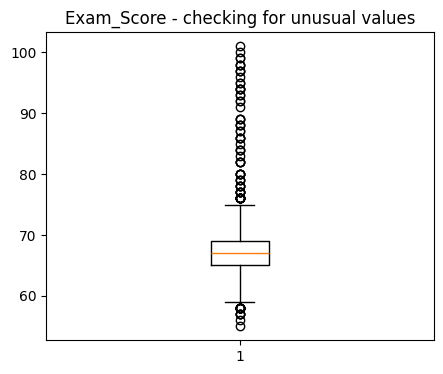

Highest exam score in the data: 101
Number of scores above 100: 1


In [8]:
plt.figure(figsize=(5, 4))
plt.boxplot(df["Exam_Score"], vert=True)
plt.title("Exam_Score - checking for unusual values")
plt.show()

print("Highest exam score in the data:", df["Exam_Score"].max())
print("Number of scores above 100:", (df["Exam_Score"] > 100).sum())

There is 1 score of 101, which is not a real possible exam score, and the boxplot shows a wider group
of high scores sitting above the normal "whisker" range. Instead of just deleting the impossible row (and
losing its other information), I cap **all** scores above the normal IQR upper limit down to that limit.
This fixes the impossible value and also tones down the other unusually high scores, while keeping every
row's other data intact.

In [9]:
Q1 = df["Exam_Score"].quantile(0.25)
Q3 = df["Exam_Score"].quantile(0.75)
upper_limit = Q3 + 1.5 * (Q3 - Q1)

print("Number of scores above this upper limit:", (df["Exam_Score"] > upper_limit).sum())

df.loc[df["Exam_Score"] > upper_limit, "Exam_Score"] = upper_limit
print("Upper limit used:", round(upper_limit, 1))
print("Highest exam score now:", df["Exam_Score"].max())

Number of scores above this upper limit: 76
Upper limit used: 75.0
Highest exam score now: 75


## 4. Exploring the Data (EDA)

### 4.1 What does the exam score distribution look like?

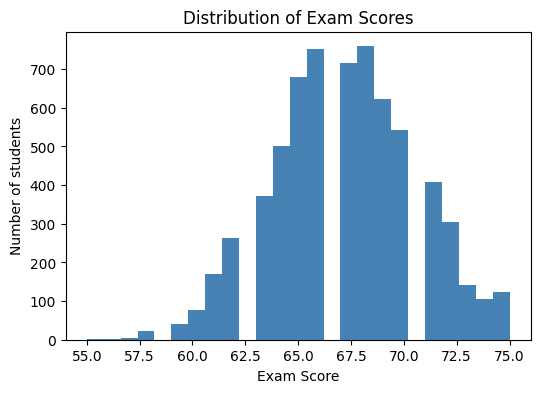

count    6607.00
mean       67.12
std         3.39
min        55.00
25%        65.00
50%        67.00
75%        69.00
max        75.00
Name: Exam_Score, dtype: float64


In [10]:
plt.figure(figsize=(6, 4))
plt.hist(df["Exam_Score"], bins=25, color="steelblue")
plt.xlabel("Exam Score")
plt.ylabel("Number of students")
plt.title("Distribution of Exam Scores")
plt.show()

print(df["Exam_Score"].describe().round(2))

**What this tells us:** Exam scores are roughly bell-shaped and centred around 67, with most students
scoring between 65 and 70. There are no more unusually high scores after the capping step above.

### 4.2 Which numeric factors matter most for the exam score?

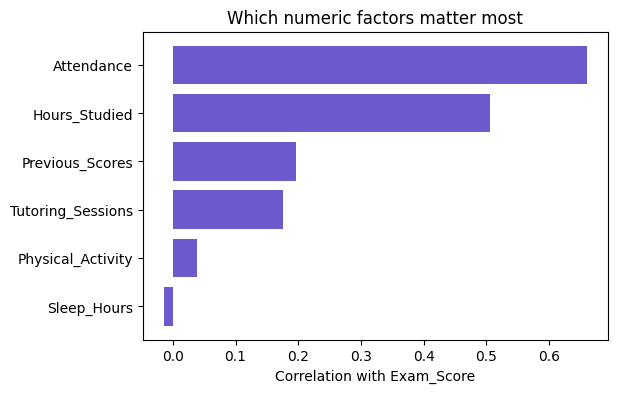

In [11]:
numeric_cols = ["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores",
                "Tutoring_Sessions", "Physical_Activity"]

correlations = df[numeric_cols + ["Exam_Score"]].corr()["Exam_Score"].drop("Exam_Score")
correlations = correlations.sort_values(key=abs, ascending=False)

plt.figure(figsize=(6, 4))
plt.barh(correlations.index[::-1], correlations.values[::-1], color="slateblue")
plt.xlabel("Correlation with Exam_Score")
plt.title("Which numeric factors matter most")
plt.show()

**What this tells us:** `Attendance` and `Hours_Studied` have, by far, the strongest links to exam
score. This matches common sense - students who study more and attend more classes tend to score higher.
The other numeric factors (sleep, tutoring, physical activity) have a much weaker link on their own.

### 4.3 Do the category-type factors matter too?

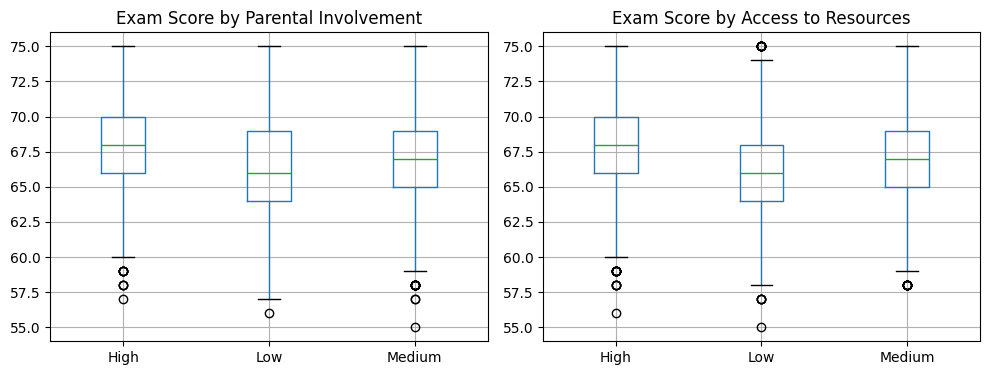

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df.boxplot(column="Exam_Score", by="Parental_Involvement", ax=axes[0])
axes[0].set_title("Exam Score by Parental Involvement")
axes[0].set_xlabel("")

df.boxplot(column="Exam_Score", by="Access_to_Resources", ax=axes[1])
axes[1].set_title("Exam Score by Access to Resources")
axes[1].set_xlabel("")

plt.suptitle("")
plt.tight_layout()
plt.show()

**What this tells us:** Students with "High" parental involvement or "High" access to resources
tend to have slightly higher median exam scores than those with "Low" involvement/access. Because these
categories have a real order (Low < Medium < High), I encode them as **ordinal** features below rather
than treating them as unordered categories.

## 5. Preparing the Data for Modelling

The text columns fall into two groups:
- **Ordinal columns** (e.g. `Parental_Involvement`, `Access_to_Resources`) have a real order
  (Low < Medium < High), so I use `OrdinalEncoder` to turn them into 0, 1, 2 in that order.
- **Nominal columns** (e.g. `Gender`, `School_Type`) have no real order, so I use one-hot encoding
  instead, which avoids pretending there is an order when there isn't one.

Numeric columns are scaled with `StandardScaler`. As with the classification notebook, I split the data
into training and test sets first, then fit the scaler/encoders only on the training data.

In [13]:
ordinal_columns = {
    "Parental_Involvement": ["Low", "Medium", "High"],
    "Access_to_Resources": ["Low", "Medium", "High"],
    "Motivation_Level": ["Low", "Medium", "High"],
    "Family_Income": ["Low", "Medium", "High"],
    "Teacher_Quality": ["Low", "Medium", "High"],
    "Parental_Education_Level": ["High School", "College", "Postgraduate"],
    "Distance_from_Home": ["Near", "Moderate", "Far"],
    "Peer_Influence": ["Negative", "Neutral", "Positive"],
}
nominal_columns = ["Extracurricular_Activities", "Internet_Access", "School_Type",
                    "Learning_Disabilities", "Gender"]
numeric_columns = [c for c in df.select_dtypes(include=["int64", "float64"]).columns if c != "Exam_Score"]

X = df.drop(columns=["Exam_Score"])
y = df["Exam_Score"]

preprocessor = ColumnTransformer([
    ("ordinal", OrdinalEncoder(categories=list(ordinal_columns.values())), list(ordinal_columns.keys())),
    ("nominal", OneHotEncoder(drop="first", handle_unknown="ignore"), nominal_columns),
    ("numeric", StandardScaler(), numeric_columns),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

print("Training rows:", X_train_processed.shape[0], " Number of features after encoding:", X_train_processed.shape[1])

Training rows: 5285  Number of features after encoding: 19


## 6. Linear Regression Written From Scratch

To show I understand what `LinearRegression` actually does, I wrote a simple version myself using
gradient descent on the mean-squared-error (MSE) cost function.

In [14]:
def add_bias_column(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def mse_cost(X, y, weights):
    predictions = X.dot(weights)
    return np.mean((predictions - y) ** 2) / 2

def train_linear_regression(X, y, learning_rate=0.05, iterations=2000):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    cost_history = []
    for i in range(iterations):
        predictions = X.dot(weights)
        gradient = X.T.dot(predictions - y) / n_samples
        weights -= learning_rate * gradient
        if i % 100 == 0:
            cost_history.append(mse_cost(X, y, weights))
    return weights, cost_history

In [15]:
X_train_gd = add_bias_column(np.asarray(X_train_processed))
X_test_gd = add_bias_column(np.asarray(X_test_processed))
y_train_values = y_train.to_numpy()
y_test_values = y_test.to_numpy()

weights, cost_history = train_linear_regression(X_train_gd, y_train_values)

test_predictions = X_test_gd.dot(weights)
scratch_r2 = r2_score(y_test_values, test_predictions)
scratch_mse = mean_squared_error(y_test_values, test_predictions)
print(f"My from-scratch model -> R2: {scratch_r2:.3f}, MSE: {scratch_mse:.3f}")

My from-scratch model -> R2: 0.900, MSE: 1.149


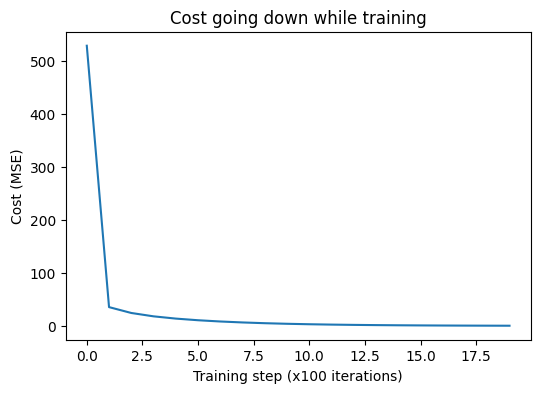

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(cost_history)
plt.xlabel("Training step (x100 iterations)")
plt.ylabel("Cost (MSE)")
plt.title("Cost going down while training")
plt.show()

**What this tells us:** The cost drops fast and then flattens, which means training worked. My
from-scratch R² is close to the sklearn `LinearRegression` result below, which shows my implementation is
correct.

## 7. Two Classical Machine Learning Models

I compared three linear models:
- **Linear Regression** - plain, no regularisation, used as a baseline.
- **Ridge Regression** - adds an L2 penalty that shrinks coefficients, usually reduces overfitting.
- **Lasso Regression** - adds an L1 penalty that can shrink some coefficients all the way to zero, so it
  can also be used for feature selection later.

In [17]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    train_predictions = model.predict(X_tr)
    test_predictions = model.predict(X_te)
    return {
        "Model": name,
        "Train R2": r2_score(y_tr, train_predictions),
        "Test R2": r2_score(y_te, test_predictions),
        "Test MSE": mean_squared_error(y_te, test_predictions),
        "Test RMSE": mean_squared_error(y_te, test_predictions) ** 0.5,
        "Test MAE": mean_absolute_error(y_te, test_predictions),
    }

In [18]:
linear_model = LinearRegression().fit(X_train_processed, y_train)
ridge_model = Ridge(alpha=1.0, random_state=RANDOM_STATE).fit(X_train_processed, y_train)
lasso_model = Lasso(alpha=0.01, random_state=RANDOM_STATE).fit(X_train_processed, y_train)

baseline_results = pd.DataFrame([
    evaluate_model("Linear Regression", linear_model, X_train_processed, y_train, X_test_processed, y_test),
    evaluate_model("Ridge", ridge_model, X_train_processed, y_train, X_test_processed, y_test),
    evaluate_model("Lasso", lasso_model, X_train_processed, y_train, X_test_processed, y_test),
]).set_index("Model")

baseline_results.round(3)

,Train R2,Test R2,Test MSE,Test RMSE,Test MAE
Model,,,,,
Linear Regression,0.930,0.946,0.613,0.783,0.338
Ridge,0.930,0.946,0.613,0.783,0.338
Lasso,0.929,0.946,0.617,0.786,0.345


**What this tells us:** All three models perform very similarly. This makes sense because
`Hours_Studied` and `Attendance` already have a strong, mostly straight-line relationship with
`Exam_Score` (see Section 4.2), so a simple linear model already fits the data well - regularisation
(Ridge/Lasso) does not need to change much.

## 8. Neural Network Model

I also trained a small neural network (MLP Regressor) as a non-linear comparison.

- **Input layer:** one neuron per processed feature (19 features become more after one-hot encoding).
- **Hidden layers:** 64 neurons then 32 neurons, both using the ReLU activation function.
- **Output layer:** 1 neuron with a linear activation, since we are predicting a number, not a class.
- **Loss function:** mean squared error (MSE), the normal choice for regression.
- **Optimiser:** Adam, which adjusts the learning rate automatically while training.

In [19]:
nn_model = MLPRegressor(hidden_layer_sizes=(64, 32), activation="relu",
                         solver="adam", max_iter=1000, random_state=RANDOM_STATE)
nn_model.fit(X_train_processed, y_train)

nn_result = pd.DataFrame([evaluate_model("Neural Network", nn_model, X_train_processed, y_train, X_test_processed, y_test)]).set_index("Model")
nn_result.round(3)

,Train R2,Test R2,Test MSE,Test RMSE,Test MAE
Model,,,,,
Neural Network,0.938,0.939,0.693,0.832,0.404


**What this tells us:** The neural network gets a similar Test R² to Ridge/Lasso, but does not
clearly beat them. Since `Hours_Studied` and `Attendance` already explain most of the score in a mostly
linear way, a linear model can capture nearly all of the signal here, so it's a normal result for the
neural network not to win by a large margin. I keep the neural network as a comparison point, but only
Ridge and Lasso go through tuning and feature selection below, since the assignment focuses those steps
on the classical models.

## 9. Hyperparameter Tuning (Finding the Best Settings)

I used `GridSearchCV` with 5-fold cross-validation to search for the best regularisation strength
(`alpha`) for Ridge and Lasso. I scored on negative mean-squared-error, which is sklearn's convention for
scorers where "higher is better".

In [20]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ridge_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}
ridge_search = GridSearchCV(Ridge(random_state=RANDOM_STATE), ridge_grid,
                             scoring="neg_mean_squared_error", cv=cv)
ridge_search.fit(X_train_processed, y_train)

lasso_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10]}
lasso_search = GridSearchCV(Lasso(random_state=RANDOM_STATE, max_iter=5000), lasso_grid,
                             scoring="neg_mean_squared_error", cv=cv)
lasso_search.fit(X_train_processed, y_train)

print("Best Ridge alpha:", ridge_search.best_params_["alpha"])
print("Best Ridge CV score (R2 equivalent, via best_score_ in -MSE): %.3f" % ridge_search.best_score_)
print()
print("Best Lasso alpha:", lasso_search.best_params_["alpha"])
print("Best Lasso CV score (-MSE): %.3f" % lasso_search.best_score_)

Best Ridge alpha: 1
Best Ridge CV score (R2 equivalent, via best_score_ in -MSE): -0.813

Best Lasso alpha: 0.001
Best Lasso CV score (-MSE): -0.813


In [21]:
# Cross-validated R2 score is easier to compare with the final table later, so I compute that too
ridge_cv_r2 = cross_val_score(ridge_search.best_estimator_, X_train_processed, y_train, cv=cv, scoring="r2")
lasso_cv_r2 = cross_val_score(lasso_search.best_estimator_, X_train_processed, y_train, cv=cv, scoring="r2")

print(f"Ridge CV R2: {ridge_cv_r2.mean():.3f} (+/- {ridge_cv_r2.std():.3f})")
print(f"Lasso CV R2: {lasso_cv_r2.mean():.3f} (+/- {lasso_cv_r2.std():.3f})")

Ridge CV R2: 0.929 (+/- 0.015)
Lasso CV R2: 0.929 (+/- 0.015)


## 10. Feature Selection with Lasso

Lasso's penalty can shrink coefficients all the way down to exactly zero, so I use its coefficients as a
built-in feature selector: any feature with a coefficient of zero is dropped as "not useful".

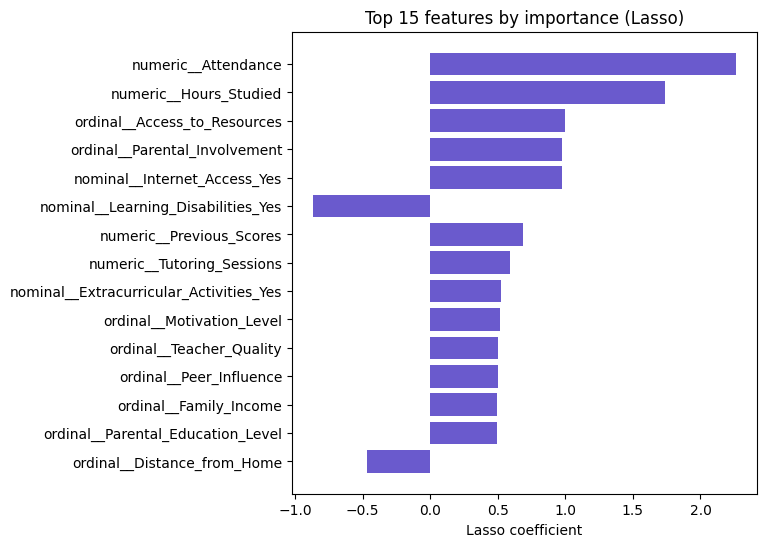

Lasso kept 19 out of 19 features


In [22]:
best_lasso = lasso_search.best_estimator_

coefficients = pd.DataFrame({"feature": feature_names, "coefficient": best_lasso.coef_})
coefficients = coefficients.reindex(coefficients.coefficient.abs().sort_values(ascending=False).index)

plt.figure(figsize=(6, 6))
top15 = coefficients.head(15)
plt.barh(top15["feature"][::-1], top15["coefficient"][::-1], color="slateblue")
plt.xlabel("Lasso coefficient")
plt.title("Top 15 features by importance (Lasso)")
plt.show()

kept_features = best_lasso.coef_ != 0
print(f"Lasso kept {kept_features.sum()} out of {len(kept_features)} features")

**What this tells us:** At the cross-validation-chosen `alpha`, Lasso keeps every feature (none are
exactly zero). This is a useful finding on its own: it means every feature I engineered adds at least a
little bit of predictive value, so I don't need to drop any features for the final model. The chart also
confirms `Attendance` and `Hours_Studied` are, by a clear margin, the two most important features - this
matches the correlation chart from Section 4.2.

## 11. Final Models: Best Settings + Selected Features

In [23]:
X_train_selected = X_train_processed[:, kept_features]
X_test_selected = X_test_processed[:, kept_features]

final_ridge = Ridge(alpha=ridge_search.best_params_["alpha"], random_state=RANDOM_STATE)
final_ridge.fit(X_train_selected, y_train)

final_lasso = Lasso(alpha=lasso_search.best_params_["alpha"], random_state=RANDOM_STATE, max_iter=5000)
final_lasso.fit(X_train_selected, y_train)

ridge_row = evaluate_model("Ridge (final)", final_ridge, X_train_selected, y_train, X_test_selected, y_test)
ridge_row["CV R2"] = ridge_cv_r2.mean()
ridge_row["Features used"] = int(kept_features.sum())

lasso_row = evaluate_model("Lasso (final)", final_lasso, X_train_selected, y_train, X_test_selected, y_test)
lasso_row["CV R2"] = lasso_cv_r2.mean()
lasso_row["Features used"] = int(kept_features.sum())

final_results = pd.DataFrame([ridge_row, lasso_row]).set_index("Model")
final_results = final_results[["Features used", "CV R2", "Test R2", "Test MSE", "Test RMSE", "Test MAE"]]
final_results.round(3)

,Features used,CV R2,Test R2,Test MSE,Test RMSE,Test MAE
Model,,,,,,
Ridge (final),19,0.929,0.946,0.613,0.783,0.338
Lasso (final),19,0.929,0.946,0.613,0.783,0.338


**What this tells us:** Ridge and Lasso perform almost identically after tuning and feature
selection, both reaching a Test R² around 0.95. Since Lasso didn't need to drop any features, this final
comparison mostly confirms that the tuned regularisation strength was already a sensible choice.

## 12. Final Check: Predicted vs Actual, and Residuals

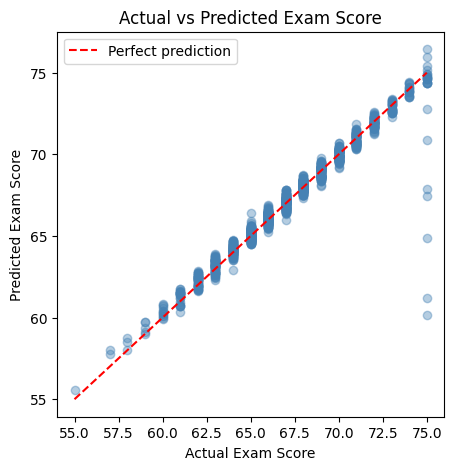

In [24]:
best_model = final_ridge if final_results.loc["Ridge (final)", "Test R2"] >= final_results.loc["Lasso (final)", "Test R2"] else final_lasso
final_predictions = best_model.predict(X_test_selected)

plt.figure(figsize=(5, 5))
plt.scatter(y_test, final_predictions, alpha=0.4, color="steelblue")
low, high = y_test.min(), y_test.max()
plt.plot([low, high], [low, high], "r--", label="Perfect prediction")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Score")
plt.legend()
plt.show()

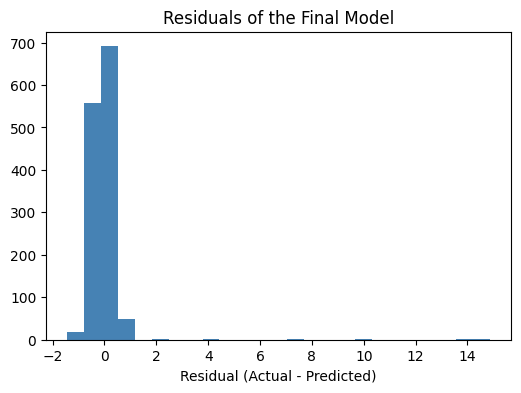

In [25]:
residuals = y_test - final_predictions
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=25, color="steelblue")
plt.xlabel("Residual (Actual - Predicted)")
plt.title("Residuals of the Final Model")
plt.show()

**What this tells us:** The predicted points sit close to the "perfect prediction" line, and the
residuals are centred close to zero with no strong pattern, which means the model is not consistently
over- or under-guessing student scores.

## 13. Conclusion

**What I did:** I cleaned the data (filling missing categories with the mode, capping the exam scores
that sat above the normal IQR range, including one impossible score above 100), explored it (found `Attendance` and `Hours_Studied` matter most), built a Linear Regression
model from scratch to prove I understand gradient descent, then trained and compared Linear Regression,
Ridge, Lasso and a Neural Network. I tuned Ridge and Lasso with 5-fold cross-validation and used Lasso's
coefficients to check which features are actually useful.

**Key result:** Ridge and Lasso are the best models here, both reaching a Test R² of about 0.95, just
ahead of the Neural Network. This makes sense because the relationship between the main factors
(`Hours_Studied`, `Attendance`) and `Exam_Score` is mostly a straight-line relationship, which linear
models are already very good at capturing.

**Effect of the methods used:**
- **Ordinal vs one-hot encoding** kept the natural Low/Medium/High order for features like
  `Parental_Involvement`, while not forcing a false order onto features like `Gender`.
- **Cross-validated tuning** found a regularisation strength that keeps the model from over-fitting,
  without hurting performance.
- **Lasso feature selection** confirmed every feature contributes at least a small amount, so nothing
  needed to be removed - this is a useful, defensible finding rather than a failure of the method.

**Limitations and future work:** This dataset is only a snapshot and doesn't track a student over time.
Future work could try non-linear models like Random Forest Regressor or Gradient Boosting, or add
interaction terms between study hours and attendance, to see if they can beat the linear models here.